In [1]:
import pandas as pd
import numpy as np
from sklearn import svm
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from joblib import dump, load
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.metrics import RocCurveDisplay

from ucimlrepo import fetch_ucirepo 
from data_preprossing import data_preprocessing


c:\Users\56316\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, X_test, y_train, y_test = data_preprocessing()

In [3]:
svm_model = load('svm_model.joblib')
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8484558118965136
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90     10193
        >50K       0.77      0.56      0.65      3374

    accuracy                           0.85     13567
   macro avg       0.82      0.75      0.78     13567
weighted avg       0.84      0.85      0.84     13567



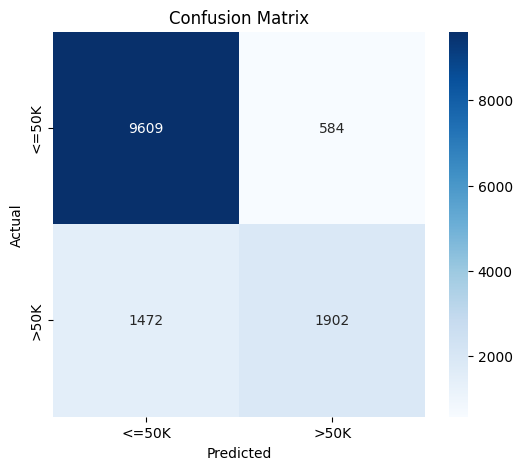

In [4]:
def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
plot_confusion_matrix(svm_model, X_test, y_test)

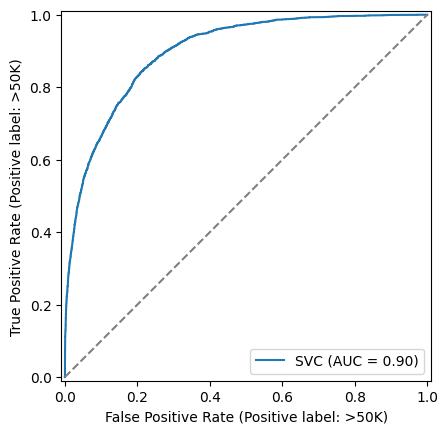

In [5]:
# Plot ROC curve
svc_disp = RocCurveDisplay.from_estimator(svm_model, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.show()

In [6]:
#svm_prob = svm.SVC(kernel='rbf',C=100,gamma=0.01,probability=True)
#svm_prob.fit(X_train, y_train)
svm_model = load('svm_model.joblib')
svm1_params = svm_model.get_params()
svm1_params['probability'] = True
svm_prob = svm.SVC(**svm1_params)
y_train = LabelEncoder().fit_transform(y_train)

svm_prob.fit(X_train, y_train)
dump(svm_prob, 'svm_prob.joblib')

['svm_prob.joblib']

In [7]:
svm_ = load('svm_prob.joblib')
X_sample = X_test[:1000]
explainer = shap.KernelExplainer(svm_.predict_proba, X_train[:50])
shap_values = explainer.shap_values(X_sample, nsamples=100)


100%|██████████| 1000/1000 [31:20<00:00,  1.88s/it]


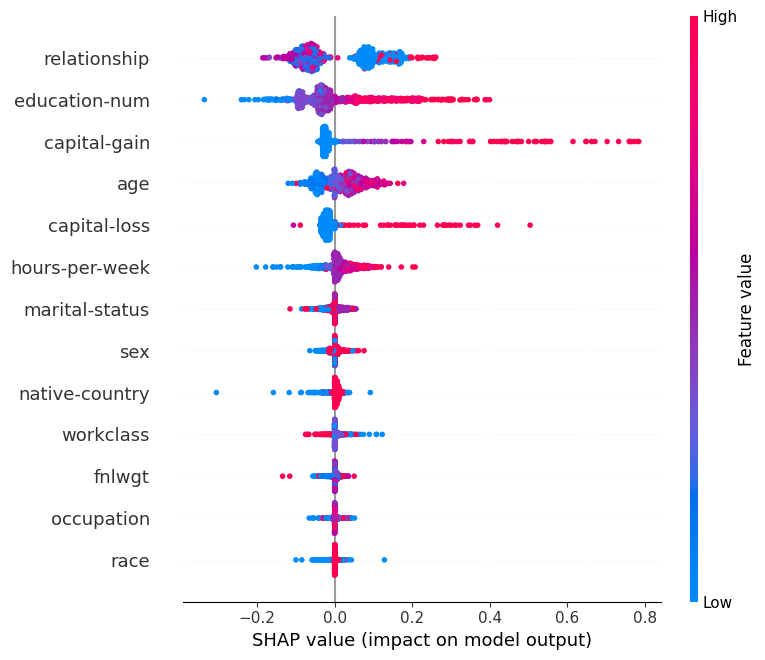

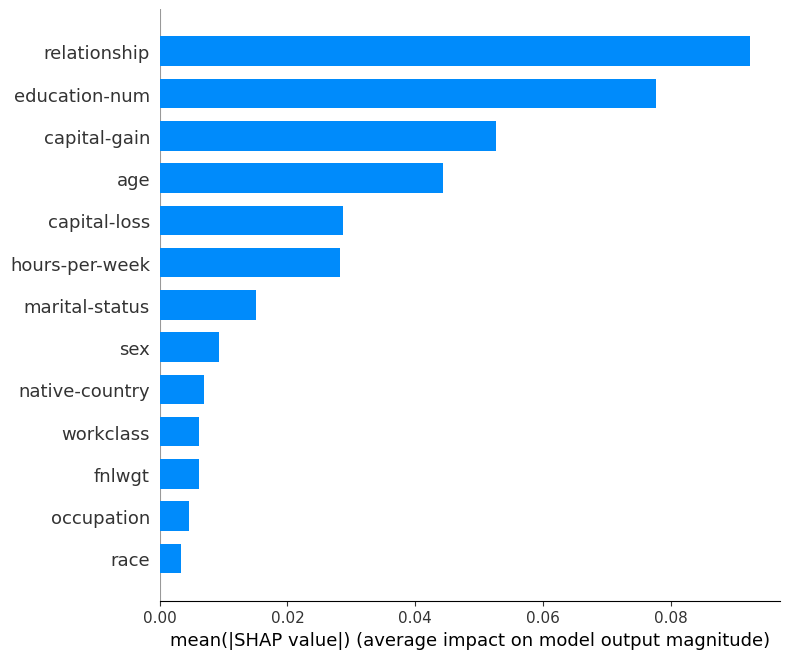

In [8]:
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets
X = X.drop('education', axis=1)
feature_names = X.columns.tolist()
X_sample_df = pd.DataFrame(X_sample, columns=feature_names)

# Then plot
shap.summary_plot(shap_values[:, :, 1], X_sample_df)
shap.summary_plot(shap_values[:, :, 1], X_sample_df,plot_type="bar")

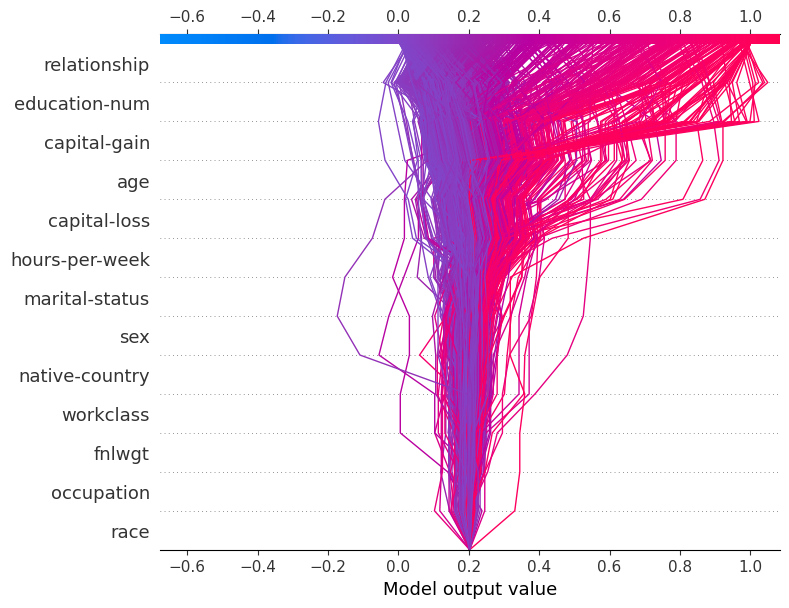

In [9]:
shap.decision_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1],
    features=X_sample,
    feature_names=feature_names
)
